<a class="anchor" id="1"></a>
# **1. Import Libraries**

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# **2. Import dataset**

In [38]:
df = pd.read_csv('quikr_car.csv')

In [39]:
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [40]:
df.shape

(892, 6)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [42]:
df['year'].unique()

array(['2007', '2006', '2018', '2014', '2015', '2012', '2013', '2016',
       '2010', '2017', '2008', '2011', '2019', '2009', '2005', '2000',
       '...', '150k', 'TOUR', '2003', 'r 15', '2004', 'Zest', '/-Rs',
       'sale', '1995', 'ara)', '2002', 'SELL', '2001', 'tion', 'odel',
       '2 bs', 'arry', 'Eon', 'o...', 'ture', 'emi', 'car', 'able', 'no.',
       'd...', 'SALE', 'digo', 'sell', 'd Ex', 'n...', 'e...', 'D...',
       ', Ac', 'go .', 'k...', 'o c4', 'zire', 'cent', 'Sumo', 'cab',
       't xe', 'EV2', 'r...', 'zest'], dtype=object)

In [43]:
df['Price'].unique()

array(['80,000', '4,25,000', 'Ask For Price', '3,25,000', '5,75,000',
       '1,75,000', '1,90,000', '8,30,000', '2,50,000', '1,82,000',
       '3,15,000', '4,15,000', '3,20,000', '10,00,000', '5,00,000',
       '3,50,000', '1,60,000', '3,10,000', '75,000', '1,00,000',
       '2,90,000', '95,000', '1,80,000', '3,85,000', '1,05,000',
       '6,50,000', '6,89,999', '4,48,000', '5,49,000', '5,01,000',
       '4,89,999', '2,80,000', '3,49,999', '2,84,999', '3,45,000',
       '4,99,999', '2,35,000', '2,49,999', '14,75,000', '3,95,000',
       '2,20,000', '1,70,000', '85,000', '2,00,000', '5,70,000',
       '1,10,000', '4,48,999', '18,91,111', '1,59,500', '3,44,999',
       '4,49,999', '8,65,000', '6,99,000', '3,75,000', '2,24,999',
       '12,00,000', '1,95,000', '3,51,000', '2,40,000', '90,000',
       '1,55,000', '6,00,000', '1,89,500', '2,10,000', '3,90,000',
       '1,35,000', '16,00,000', '7,01,000', '2,65,000', '5,25,000',
       '3,72,000', '6,35,000', '5,50,000', '4,85,000', '3,29,5

In [44]:
df['kms_driven'].unique()

array(['45,000 kms', '40 kms', '22,000 kms', '28,000 kms', '36,000 kms',
       '59,000 kms', '41,000 kms', '25,000 kms', '24,530 kms',
       '60,000 kms', '30,000 kms', '32,000 kms', '48,660 kms',
       '4,000 kms', '16,934 kms', '43,000 kms', '35,550 kms',
       '39,522 kms', '39,000 kms', '55,000 kms', '72,000 kms',
       '15,975 kms', '70,000 kms', '23,452 kms', '35,522 kms',
       '48,508 kms', '15,487 kms', '82,000 kms', '20,000 kms',
       '68,000 kms', '38,000 kms', '27,000 kms', '33,000 kms',
       '46,000 kms', '16,000 kms', '47,000 kms', '35,000 kms',
       '30,874 kms', '15,000 kms', '29,685 kms', '1,30,000 kms',
       '19,000 kms', nan, '54,000 kms', '13,000 kms', '38,200 kms',
       '50,000 kms', '13,500 kms', '3,600 kms', '45,863 kms',
       '60,500 kms', '12,500 kms', '18,000 kms', '13,349 kms',
       '29,000 kms', '44,000 kms', '42,000 kms', '14,000 kms',
       '49,000 kms', '36,200 kms', '51,000 kms', '1,04,000 kms',
       '33,333 kms', '33,600 kms', '5,

In [45]:
df['fuel_type']. unique()

array(['Petrol', 'Diesel', nan, 'LPG'], dtype=object)

## Quality
- `year` has many non-year values
- convert `year` type from object to int
- `Price` has 'ask for price'
- convert `Price` type from object to int
- `kms_driven` has 'kms' string with the integers
- `kms_driven` has NaN values
- `fuel_type` has NaN values
- keep the first 3 words only from the `name`

# **3. Data Cleaning**

In [46]:
backup = df.copy()

In [47]:
#str.isnumeric() returns True if all characters in the string are numeric characters (digits, superscripts, or fractions) and there is at least one character, otherwise False.
df = df[df['year'].str.isnumeric()]

In [48]:
df['year'] = df['year'].astype(int)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 842 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        842 non-null    object
 1   company     842 non-null    object
 2   year        842 non-null    int64 
 3   Price       842 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: int64(1), object(5)
memory usage: 46.0+ KB


the non year values are cleaned and the dara type of the `year` feature is changed into int

In [50]:
df = df[df['Price'] != 'Ask For Price']

In [51]:
df['Price'] = df['Price'].str.replace(',', '').astype(int)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 819 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        819 non-null    object
 1   company     819 non-null    object
 2   year        819 non-null    int64 
 3   Price       819 non-null    int64 
 4   kms_driven  819 non-null    object
 5   fuel_type   816 non-null    object
dtypes: int64(2), object(4)
memory usage: 44.8+ KB


the non price values are removed, ',' character is removed from integers values and the `Price` variable becomes int

In [53]:
df['kms_driven'] = df['kms_driven'].str.split(' ').str.get(0).str.replace(',', '')

`kms_driven` variable is splitted by space to contain lists consist of an integer and a 'kms' to easily remove the 'kms' word, get(0) is used to keep the first element only, and finally we removed ',' character from integers

In [54]:
df = df[df['kms_driven'].str.isnumeric()]

take the numeric values only in `kms_driven` variable after cleaning and processing the numeric values

In [55]:
df['kms_driven'] = df['kms_driven'].astype(int)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 817 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        817 non-null    object
 1   company     817 non-null    object
 2   year        817 non-null    int64 
 3   Price       817 non-null    int64 
 4   kms_driven  817 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 44.7+ KB


In [57]:
# ~ means exclude these rows and take the others
df = df[~df['fuel_type'].isna()]

In [58]:
df['fuel_type'].isna().sum()

np.int64(0)

NaN values in `fuel_type` variable is removed

In [59]:
df['name'].str.split(' ').str.slice(0,3).str.join(' ')

,name
0,Hyundai Santro Xing
1,Mahindra Jeep CL550
3,Hyundai Grand i10
4,Ford EcoSport Titanium
6,Ford Figo
...,...
883,Maruti Suzuki Ritz
885,Tata Indica V2
886,Toyota Corolla Altis
888,Tata Zest XM


the first 3 names in `name` variable are taken by splitting by space then taking the first 3 names by slicing and finally rejoining them by space

In [60]:
df

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
6,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
883,Maruti Suzuki Ritz VXI ABS,Maruti,2011,270000,50000,Petrol
885,Tata Indica V2 DLE BS III,Tata,2009,110000,30000,Diesel
886,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
888,Tata Zest XM Diesel,Tata,2018,260000,27000,Diesel


since alot of rows are removed, we need to reindex the dataframe

In [61]:
df = df.reset_index(drop=True) # to drop the previous index

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    int64 
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 38.4+ KB


<Figure size 1500x500 with 0 Axes>

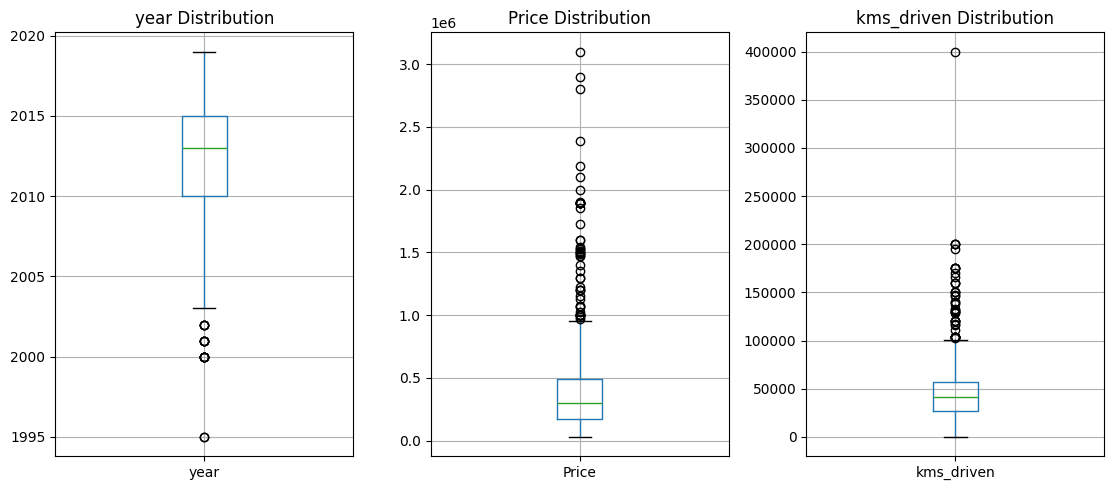

In [80]:
# Draw boxplots to visualize outliers in numerical variables
plt.figure(figsize=(15, 5))
# List of numerical columns to visualize for outliers
columns = ['year', 'Price', 'kms_driven']

# Set the figure size for the subplots
plt.figure(figsize=(15, 5))

# Iterate through the columns to generate boxplots dynamically
for i, col in enumerate(columns, 1):
    plt.subplot(1, 4, i)  # Create a subplot for each column
    df.boxplot(column=col) # Plot the boxplot for the specific column
    plt.title(f'{col} Distribution') # Add a title for each subplot

# Adjust layout to prevent overlap between subplots
plt.tight_layout()
plt.show()

In [81]:
df.describe()

,year,Price,kms_driven
count,815.000000,8.150000e+02,815.000000
mean,2012.442945,4.017933e+05,46277.096933
std,4.005079,3.815888e+05,34318.459638
min,1995.000000,3.000000e+04,0.000000
25%,2010.000000,1.750000e+05,27000.000000
50%,2013.000000,2.999990e+05,41000.000000
75%,2015.000000,4.900000e+05,56879.000000
max,2019.000000,3.100000e+06,400000.000000


In [82]:
df = df[df['Price']<6e6].reset_index(drop=True)

it is obvious that the max in `Price` is an outlier as it is e6 not even e5 same for the 400000 value in `kms_driven`

In [83]:
df.to_csv('cleaned_car.csv')

In [84]:
X = df.drop(columns='Price')
y = df['Price']

# **4. Data Preprocessing**

## **4.1. Declare feature vector and target variable**

In [86]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.2, random_state=661 )

## **4.2. Encoding**

In [92]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

In [88]:
ohe = OneHotEncoder()
ohe.fit(X[['name', 'company', 'fuel_type']])

OneHotEncoder()

In [89]:
# Configure the column transformer to apply One-Hot Encoding using pre-defined categories (from the previously fitted encoder),
# while ensuring all other columns remain untouched (passthrough).
column_trans = make_column_transformer((OneHotEncoder(categories= ohe.categories_), ['name', 'company', 'fuel_type']), remainder = 'passthrough')

# **5. Model Building**

In [103]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.pipeline import make_pipeline

In [94]:
lr = LinearRegression()

In [95]:
# Create a pipeline that bundles the data transformation step and the model (Linear Regression)
# so they execute sequentially in a single flow.
pipe = make_pipeline(column_trans, lr) # take column_trans as an input to lr

In [96]:
pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['Audi A3 Cabriolet 40 TFSI',
       'Audi A4 1.8 TFSI Multitronic Premium Plus',
       'Audi A4 2.0 TDI 177bhp Premium', 'Audi A6 2.0 TDI Premium',
       'Audi A8', 'Audi Q3 2.0 TDI quattro Premium',
       'Audi Q5 2.0 TDI quattro Premium Plus', 'Audi Q7',
       'BMW 3 Series 320d...
                                                                            array(['Audi', 'BMW', 'Chevrolet', 'Datsun', 'Fiat', 'Force', 'Ford',
       'Hindustan', 'Honda', 'Hyundai', 'Jaguar', 'Jeep', 'Land',
       'Mahindra', 'Maruti', 'Mercedes', 'Mini', 'Mitsubishi', 'Nissan',
       'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo'],
      dtype=object),
                                                                            array(['Diesel', 'LPG', 'Petrol'], dtype=object)]),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('linearregression', LinearRegression())])

In [97]:
# Use the trained pipeline to predict target values for the test dataset,
# automatically applying the necessary transformations (encoding) to the input features.
y_pred = pipe.predict(X_test)

In [102]:
print(r2_score(y_test, y_pred))

0.7287201156622845


In [107]:
pipe.predict(pd.DataFrame([['Maruti Suzuki Swift', 'Maruti', 2019, 100, 'Petrol']], columns= ['name', 'company', 'year', 'kms_driven', 'fuel_type']))

array([458227.32735473])

# **6. Deployment Preperation**

In [122]:
# Save the trained pipeline object to a binary file named 'LinearRegression.pkl'
# to allow for future use or deployment without re-training the model.
pickle.dump(pipe, open('LinearRegression.pkl', 'wb'))

# Dump the processed dataframe
pickle.dump(df, open('car.pkl', 'wb'))